In [14]:
!pip install lightkurve

In [15]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt


In [16]:
# STEP 1: Download data
target = "Kepler-10"
tpf = lk.search_targetpixelfile(target, mission="Kepler").download()


/usr/local/lib/python3.12/dist-packages/lightkurve/search.py:420: LightkurveWarning: Warning: 49 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


In [17]:
# STEP 2: Light curve
lc = tpf.to_lightcurve(aperture_mask=tpf.pipeline_mask)
lc = lc.remove_nans()

In [18]:

# STEP 3: Flatten
flat_lc = lc.flatten(window_length=401)


In [19]:
# STEP 4: BLS
periods = np.linspace(0.5, 10, 10000)
bls = flat_lc.to_periodogram(method="bls", period=periods)

best_period = bls.period_at_max_power


In [20]:
# STEP 5: Fold
folded_lc = flat_lc.fold(period=best_period, epoch_time=best_period/2)


In [21]:
# STEP 6: Transit depth
flux = folded_lc.flux
flux = flux[~np.isnan(flux)]
transit_depth = 1 - np.median(np.sort(flux)[:100])


In [22]:
# STEP 7: Radius ratio
rp_rs = np.sqrt(transit_depth)


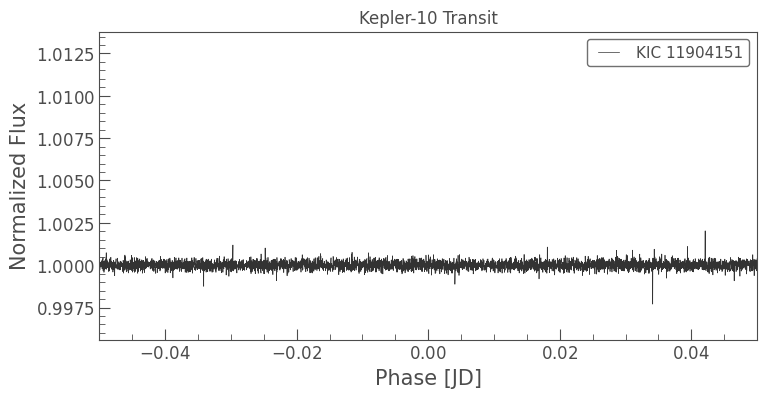

In [23]:
# STEP 8: Plot
ax = folded_lc.plot()
ax.set_xlim(-0.05, 0.05)

plt.title("Kepler-10 Transit")
plt.show()

In [24]:
#flux = folded_lc.flux
flux = flux[~np.isnan(flux)]

sorted_flux = np.sort(flux)
transit_depth = 1 - np.median(sorted_flux[:100])

rp_rs = np.sqrt(transit_depth)

print("Transit Depth:", transit_depth)
print("Rp/Rs:", rp_rs)

Transit Depth: 0.0008653389462757177
Rp/Rs: 0.0294166440348949


In [25]:
time = folded_lc.time.value

threshold = np.median(flux) - 0.5 * transit_depth
in_transit = flux < threshold

duration = time[in_transit].max() - time[in_transit].min()

print("Transit Duration:", duration)

Transit Duration: 0.8345009873658075


In [26]:
print("\n===== FINAL RESULTS =====")

print(f"Orbital Period: {best_period:.4f} days")
print(f"Transit Depth: {transit_depth:.6f}")
print(f"Rp/Rs: {rp_rs:.4f}")
print(f"Transit Duration: {duration:.4f} days")


===== FINAL RESULTS =====
Orbital Period: 0.8373 d days
Transit Depth: 0.000865
Rp/Rs: 0.0294
Transit Duration: 0.8345 days


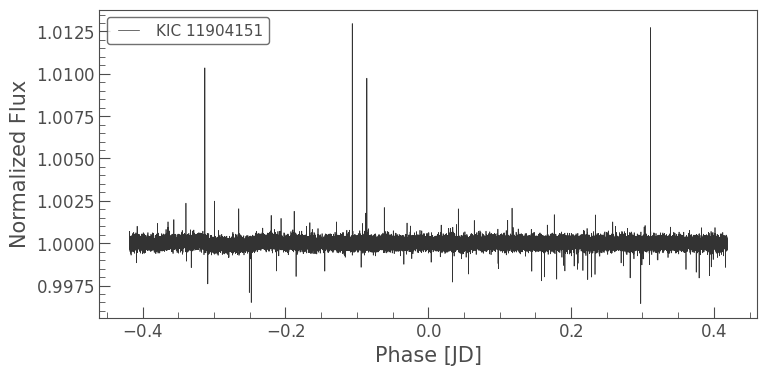

In [27]:
folded_lc.plot()
plt.savefig("kepler10_transit.png", dpi=300)